In [ ]:
! pip install gwpy

In [1]:
from gwpy.timeseries import TimeSeries
gwpy_strain = TimeSeries.read('challenge2.gwf', channel="H1:CHALLENGE2")

/opt/conda/lib/python3.8/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(True)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [3]:
print(gwpy_strain) #checking the data

TimeSeries([ 8.75332715e-22,  1.27597248e-22,  1.88838802e-22,
            ..., -1.91886478e-23, -2.10989354e-22,
             2.30287965e-22]
           unit: ct,
           t0: -64.0 s,
           dt: 0.000244140625 s,
           name: H1:CHALLENGE2,
           channel: None)


In [4]:
data = gwpy_strain #renaming the data

In [5]:
data.duration

<Quantity 128. s>

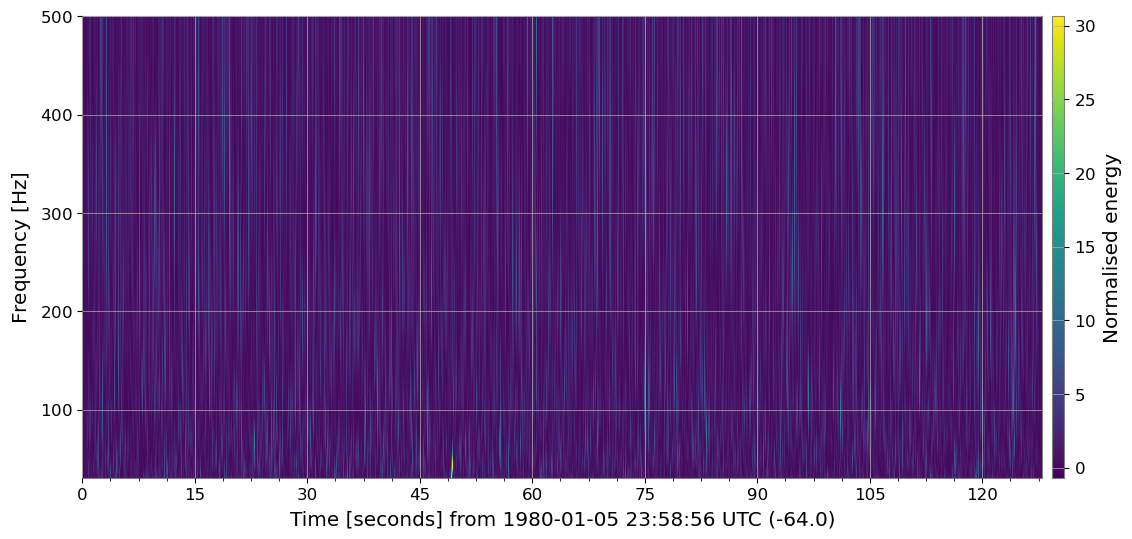

In [9]:
data_q = data.q_transform(frange=(30, 500)) #plotting the data as a spectrogram with qtransform
qplot = data_q.plot()
qplot.colorbar(label="Normalised energy")

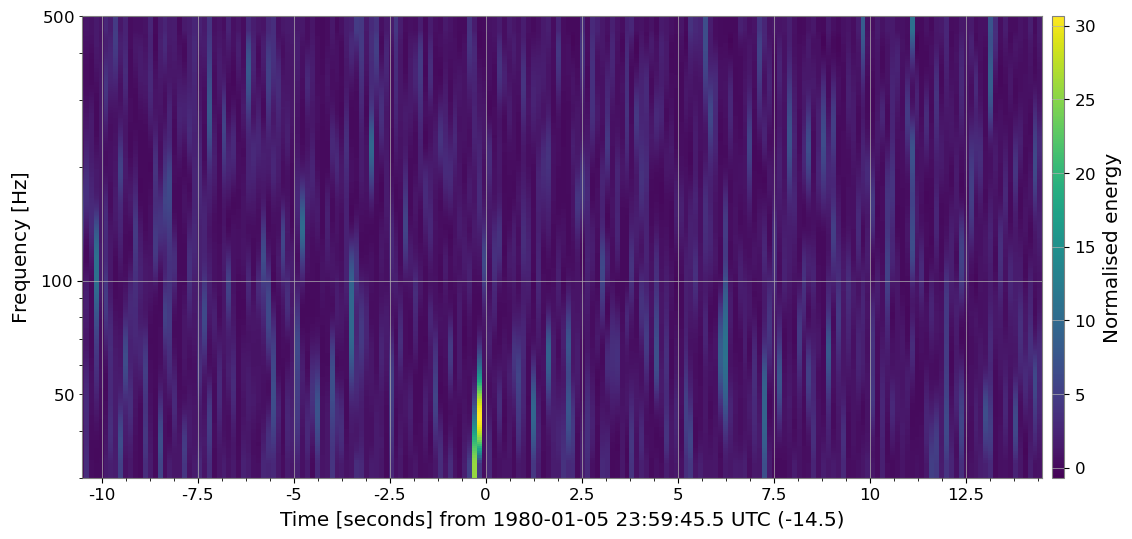

In [22]:
ax = qplot.gca() #changing scales to make the plot more clear
ax.set_epoch(-14.5)
ax.set_xlim(-25,0)
ax.set_ylim(30, 500)
ax.set_yscale("log")
qplot  #refresh

#judging from this plot, the time of the merger would be approximately at t = -14.5

In [24]:
! pip install -q pycbc


[notice] A new release of pip is available: 23.3.1 -> 24.0
[notice] To update, run: pip install --upgrade pip


In [26]:
from pycbc.waveform import get_td_waveform
import pylab

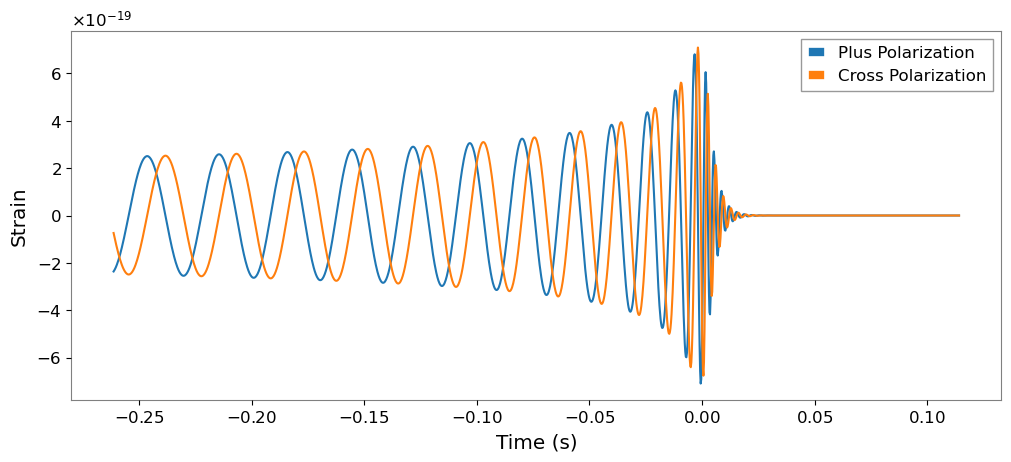

In [29]:
hp, hc = get_td_waveform(approximant="SEOBNRv4_opt", #making the time-domain template waveform
                         mass1=30,
                         mass2=30,
                         delta_t= 0.000244140625, #using the same delta_t
                         f_lower=30)

pylab.figure(figsize=pylab.figaspect(0.4))
pylab.plot(hp.sample_times, hp, label='Plus Polarization')
pylab.plot(hp.sample_times, hc, label='Cross Polarization')
pylab.xlabel('Time (s)')
pylab.ylabel('Strain')
pylab.legend()
pylab.grid()
pylab.show()

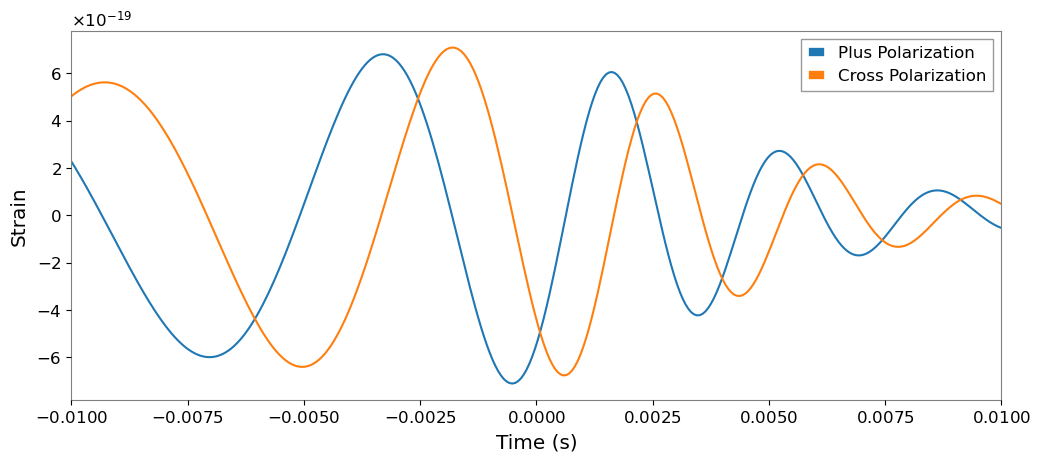

In [28]:
#Zoom in near the merger time
pylab.figure(figsize=pylab.figaspect(0.4))
pylab.plot(hp.sample_times, hp, label='Plus Polarization')
pylab.plot(hp.sample_times, hc, label='Cross Polarization')
pylab.xlabel('Time (s)')
pylab.ylabel('Strain')
pylab.xlim(-.01, .01)
pylab.legend()
pylab.grid()
pylab.show()

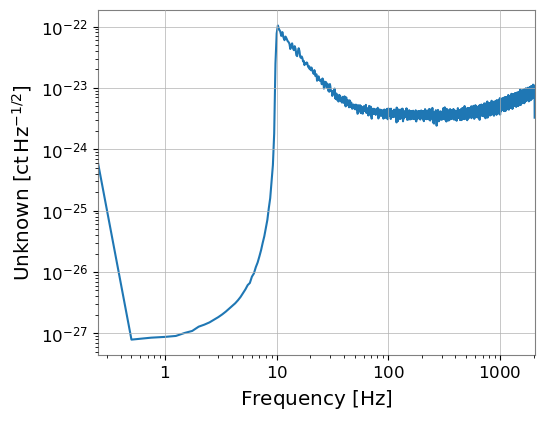

In [41]:
#calculating PSD of the data
asd = data.asd(fftlength=4, method="median")
asdplot = asd.plot()
asdplot.show(warn=False)

In [62]:
sample_rate = 1.0/data.dt #calculating the sampling rate

print(sample_rate)


4096.0 1 / s


In [108]:
ax = asdplot.gca() #setting parameters for the plot, x and y limits. plotting PSD
ax.set_xlim(20, 2048)
ax.set_ylim(1e-24, 1e-22)
asdplot


In [109]:
hp = hp / max(numpy.correlate(hp, hp, mode='full'))**0.5

Text(0, 0.5, 'Normalized amplitude')

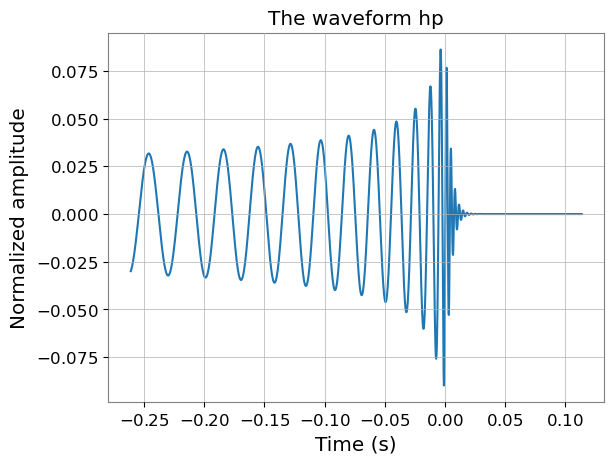

In [102]:
pylab.figure()
pylab.title("The waveform hp")
pylab.plot(hp.sample_times, hp)
pylab.xlabel('Time (s)')
pylab.ylabel('Normalized amplitude')

In [103]:
cross_correlation = numpy.zeros([len(data)-len(hp)])
hp_numpy = hp.numpy()
data_array = data.value

In [104]:
for i in range(len(data) - len(hp_numpy)):
    cross_correlation[i] = (hp_numpy * data_array[i:i+len(hp_numpy)]).sum()

Text(0, 0.5, 'Cross-correlation')

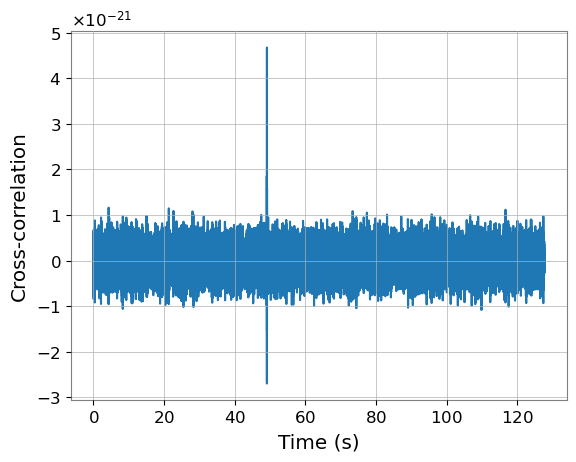

In [105]:
pylab.figure() #plotting the snr timeseries
times = numpy.arange(len(data) - len(hp_numpy)) / 4096
snrplot = pylab.plot(times, cross_correlation)
pylab.xlabel('Time (s)')
pylab.ylabel('Cross-correlation')

In [107]:
Matched_SNR = max(cross_correlation)  #finding the value for the matched snr
print("Matched filter SNR for the signal:", Matched_SNR)

Matched filter SNR for the signal: 4.674833226580958e-21
